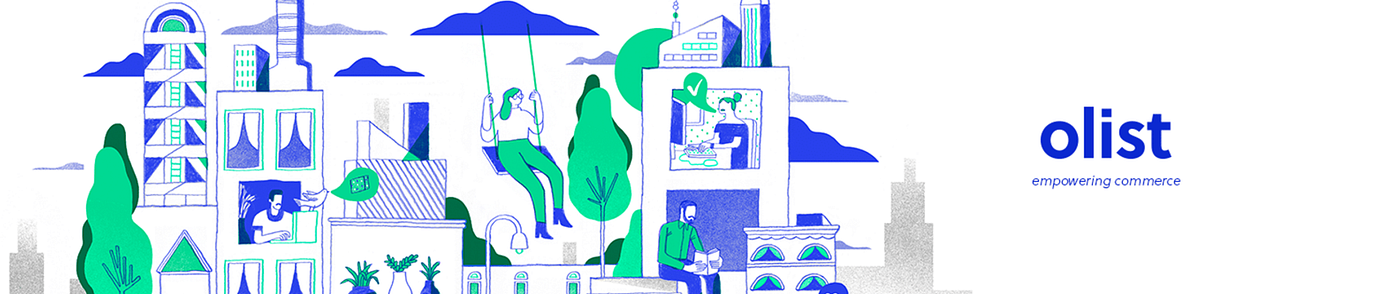

#  1️⃣ Understanding the Dataset


#  2️⃣ Data Loading


In [1]:
import pandas as pd

# Load all 9 Olist datasets
customers = pd.read_csv('olist_customers_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
geolocation = pd.read_csv('olist_geolocation_dataset.csv')
category_translation = pd.read_csv('product_category_name_translation.csv')

In [2]:
# Puting them in a dictionary for easy looping
datasets = {
    'customers': customers,
    'orders': orders,
    'order_items': order_items,
    'payments': payments,
    'reviews': reviews,
    'products': products,
    'sellers': sellers,
    'geolocation': geolocation,
    'category_translation': category_translation
}

# Quick check for each table: shape, columns, dtypes, missing values, duplicates
for name, df in datasets.items():
    print(f"===== {name} =====")
    print("Shape:", df.shape)
    print("Columns:", list(df.columns))
    print("Missing values:\n", df.isnull().sum()[df.isnull().sum() > 0])
    print("Duplicates:", df.duplicated().sum())
    print()

===== customers =====
Shape: (99441, 5)
Columns: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']
Missing values:
 Series([], dtype: int64)
Duplicates: 0

===== orders =====
Shape: (99441, 8)
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
Missing values:
 order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64
Duplicates: 0

===== order_items =====
Shape: (112650, 7)
Columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
Missing values:
 Series([], dtype: int64)
Duplicates: 0

===== payments =====
Shape: (103886, 5)
Columns: ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']
Missing values:
 Series([], dtype: int64)

# 3️⃣ Data Cleaning


In [3]:
# 1. Geolocation: remove duplicates (There are far too many, and leaving them makes no sense, so we will delete them.)
geolocation = geolocation.drop_duplicates()
print("Geolocation after cleaning:", geolocation.shape)

# 2. Products: handle missing category & dimensions
products['product_category_name'] = products['product_category_name'].fillna('unknown')
products = products.dropna(subset=['product_weight_g', 'product_length_cm', 
                                     'product_height_cm', 'product_width_cm'])

# 3. Orders: convert date columns to datetime (keep missing as NaT for now)
date_cols = ['order_purchase_timestamp', 'order_approved_at', 
             'order_delivered_carrier_date', 'order_delivered_customer_date', 
             'order_estimated_delivery_date']
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

print("Orders dtypes:\n", orders[date_cols].dtypes)

Geolocation after cleaning: (738332, 5)
Orders dtypes:
 order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object


In [4]:
# order_purchase_timestamp as the basis (actual order time)
orders['order_year'] = orders['order_purchase_timestamp'].dt.year
orders['order_month'] = orders['order_purchase_timestamp'].dt.month
orders['order_day'] = orders['order_purchase_timestamp'].dt.day
orders['order_weekday'] = orders['order_purchase_timestamp'].dt.day_name()
orders['order_quarter'] = orders['order_purchase_timestamp'].dt.quarter

In [5]:
# We look at all the existing cases and their count.
print(orders['order_status'].value_counts())

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [6]:
# We filter for delivered orders only, as they are the only ones for which we can accurately calculate delivery metrics.
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()

print("Shape after filtering:", orders_delivered.shape)

# دلوقتي نحسب delivery_delay و delivery_days بأمان
orders_delivered['delivery_days'] = (orders_delivered['order_delivered_customer_date'] - orders_delivered['order_purchase_timestamp']).dt.days

orders_delivered['delivery_delay'] = (orders_delivered['order_delivered_customer_date'] - orders_delivered['order_estimated_delivery_date']).dt.days

orders_delivered['is_late'] = (orders_delivered['delivery_delay'] > 0).astype(int)

print(orders_delivered[['delivery_days', 'delivery_delay', 'is_late']].describe())

Shape after filtering: (96478, 13)
       delivery_days  delivery_delay       is_late
count   96470.000000    96470.000000  96478.000000
mean       12.093604      -11.875889      0.067725
std         9.551380       10.182105      0.251275
min         0.000000     -147.000000      0.000000
25%         6.000000      -17.000000      0.000000
50%        10.000000      -12.000000      0.000000
75%        15.000000       -7.000000      0.000000
max       209.000000      188.000000      1.000000


In [7]:
# Let's look at the strangest values
print(orders_delivered.sort_values('delivery_days', ascending=False)[['order_id', 'delivery_days', 'delivery_delay']].head(10))

                               order_id  delivery_days  delivery_delay
19590  ca07593549f1816d26a572e06dc1eab6          209.0           181.0
55619  1b3190b2dfa9d789e1f14c05b647a14a          208.0           188.0
61610  440d0d17af552815d15a9e41abe49359          195.0           165.0
70307  2fb597c2f772eca01b1f5c561bf6cc7b          194.0           155.0
89130  285ab9426d6982034523a855f55a885e          194.0           166.0
38509  0f4519c5f1c541ddec9f21b3bddd533a          194.0           161.0
11399  47b40429ed8cce3aee9199792275433f          191.0           175.0
81401  2fe324febf907e3ea3f2aa9650869fa5          189.0           167.0
54480  2d7561026d542c8dbd8f0daeadf67a43          188.0           159.0
68769  c27815f7e3dd0b926b58552628481575          187.0           162.0


In [8]:
# Percentage of "disastrous" orders (e.g., delays of more than 30 days)
extreme_delay = (orders_delivered['delivery_delay'] > 30).sum()
print(f"عدد الطلبات بتأخير أكتر من 30 يوم: {extreme_delay}")
print(f"النسبة: {extreme_delay / len(orders_delivered) * 100:.2f}%")

عدد الطلبات بتأخير أكتر من 30 يوم: 345
النسبة: 0.36%


In [9]:
products['product_category_name'] = products['product_category_name'].fillna('unknown')
products = products.dropna(subset=['product_weight_g', 'product_length_cm', 
                                     'product_height_cm', 'product_width_cm'])
print("Products shape after cleaning:", products.shape)

Products shape after cleaning: (32949, 9)


# Category Translation (دمج الأسماء الإنجليزية):

In [10]:
# We merge the English translation of category names with the products table.
products = products.merge(category_translation, on='product_category_name', how='left')
print(products[['product_category_name', 'product_category_name_english']].head())

   product_category_name product_category_name_english
0             perfumaria                     perfumery
1                  artes                           art
2          esporte_lazer                sports_leisure
3                  bebes                          baby
4  utilidades_domesticas                    housewares


### 📊 الوضع الحالي للبيانات ✅

| الجدول | الحالة |
| :--- | :--- |
| **customers** | نضيف من الأول |
| **orders** | اتنضف + اتضاف عليه features (`delivery_days`, `delay`, `is_late`) |
| **order_items** | نضيف من الأول |
| **payments** | نضيف من الأول |
| **reviews** | مسبينها زي ما هي (النصوص للـ NLP بعدين) |
| **products** | اتنضف + اتضاف الترجمة الإنجليزية |
| **sellers** | نضيف من الأول |
| **geolocation** | اتنضف من الـ duplicates |
| **category_translation** | مدموج جوه products |

# 4️⃣ SQL / Data Integration

In [11]:
from sqlalchemy import create_engine

username = 'postgres'
password = '1999'
host = 'localhost'
port = '5432'
database = 'olist_db'  

engine = create_engine(f'postgresql://{username}:{password}@{host}:{port}/{database}')

In [12]:
datasets_clean = {
    'customers': customers,
    'orders': orders_delivered,  # The cleaned-up version containing the features
    'order_items': order_items,
    'payments': payments,
    'reviews': reviews,
    'products': products,
    'sellers': sellers,
    'geolocation': geolocation
}

for table_name, df in datasets_clean.items():
    df.to_sql(table_name, engine, if_exists='replace', index=False)
    print(f"✅ تم رفع {table_name} — {df.shape[0]} صف")

✅ تم رفع customers — 99441 صف
✅ تم رفع orders — 96478 صف
✅ تم رفع order_items — 112650 صف
✅ تم رفع payments — 103886 صف
✅ تم رفع reviews — 99224 صف
✅ تم رفع products — 32949 صف
✅ تم رفع sellers — 3095 صف
✅ تم رفع geolocation — 738332 صف


In [13]:
query = """
SELECT 
    o.order_id,
    o.customer_id,
    o.order_status,
    o.order_purchase_timestamp,
    o.order_year,
    o.order_month,
    o.order_weekday,
    o.order_quarter,
    o.delivery_days,
    o.delivery_delay,
    o.is_late,
    c.customer_state,
    c.customer_city,
    oi.product_id,
    oi.price,
    oi.freight_value,
    p.product_category_name_english,
    pay.payment_type,
    pay.payment_installments,
    pay.payment_value,
    r.review_score
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN order_items oi ON o.order_id = oi.order_id
JOIN products p ON oi.product_id = p.product_id
JOIN payments pay ON o.order_id = pay.order_id
LEFT JOIN reviews r ON o.order_id = r.order_id
"""

main_df = pd.read_sql(query, engine)
print("Shape:", main_df.shape)
print(main_df.head())

Shape: (115700, 21)
                           order_id                       customer_id  \
0  f5eda0ded77c1293b04c953138c8331d  68f2b37558e27791155db34bcded5ac0   
1  f30149f4a8882a08895b6a242aa0d612  86c180c33f454b35e1596a99da3dddc4   
2  6f0dfb5b5398b271cc6bbd9ee263530e  8517e7c86998bf39a540087da6f115d9   
3  a6c1ae4d48280b5b3c43231ac6afd701  8cefa3f70ed73678ae31bd3ebf441aff   
4  c9a34c30282dc36d017bc912f8d8dc91  f1375b843314f00de278b414ac4c958a   

  order_status order_purchase_timestamp  order_year  order_month  \
0    delivered      2017-12-12 19:20:28        2017           12   
1    delivered      2018-05-20 18:45:21        2018            5   
2    delivered      2018-08-01 22:00:33        2018            8   
3    delivered      2018-04-03 09:24:12        2018            4   
4    delivered      2017-09-17 20:45:13        2017            9   

  order_weekday  order_quarter  delivery_days  delivery_delay  ...  \
0       Tuesday              4           10.0           -13.0 

In [14]:
# 1. Payments per order (if there is more than one payment method)
payments_agg = payments.groupby('order_id').agg(
    payment_value=('payment_value', 'sum'),
    payment_installments=('payment_installments', 'max'),
    payment_type=('payment_type', 'first')   # Let's take the first type of payment as a representative.
).reset_index()

# 2. Grouping `order_items` for each order (if there is more than one product in the order)
items_agg = order_items.groupby('order_id').agg(
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum'),
    num_items=('order_item_id', 'count'),
    product_id=('product_id', 'first')   # The first product as a representative example (or you could leave this for a separate analysis).
).reset_index()

# 3. We combine everything into a single order.main_df = orders_delivered.merge(customers, on='customer_id', how='left')
main_df = main_df.merge(items_agg, on='order_id', how='left')
main_df = main_df.merge(payments_agg, on='order_id', how='left')
main_df = main_df.merge(reviews[['order_id', 'review_score']], on='order_id', how='left')

# We add the English category name after retrieving the main product.
main_df = main_df.merge(products[['product_id', 'product_category_name_english']], 
                          on='product_id', how='left')

print("Shape:", main_df.shape)
print(main_df['order_id'].duplicated().sum(), "orders مكررة")

Shape: (97007, 29)
529 orders مكررة


In [16]:
# Let's verify first.
print("Duplicate order_id in reviews:", reviews['order_id'].duplicated().sum())

# Aggregating: We use the average score if there is more than one rating.
reviews_agg = reviews.groupby('order_id').agg(
    review_score=('review_score', 'mean')
).reset_index()

# We use reviews_agg instead of reviews in the merge.
main_df = orders_delivered.merge(customers, on='customer_id', how='left')
main_df = main_df.merge(items_agg, on='order_id', how='left')
main_df = main_df.merge(payments_agg, on='order_id', how='left')
main_df = main_df.merge(reviews_agg, on='order_id', how='left')
main_df = main_df.merge(products[['product_id', 'product_category_name_english']], 
                          on='product_id', how='left')

print("Shape:", main_df.shape)
print(main_df['order_id'].duplicated().sum(), "orders مكررة")

Duplicate order_id in reviews: 551
Shape: (96478, 29)
0 orders مكررة


In [15]:
# We're making sure no unexpected missing items have appeared from the merges.
print(main_df.isnull().sum()[main_df.isnull().sum() > 0])

order_approved_at                  14
order_delivered_carrier_date        2
order_delivered_customer_date       8
delivery_days                       8
delivery_delay                      8
payment_value                       1
payment_installments                1
payment_type                        1
review_score                      646
product_category_name_english    1387
dtype: int64


# تحليل سريع للـ missing الجديدة
### 📊 تحليل القيمة المفقودة (Missing Values Analysis) ✅

* **`order_approved_at`, `delivered_carrier/customer_date`, `delivery_days/delay`** *(8-14 صف)*:
  * **السبب:** عدد ضئيل جدًا من إجمالي 96,478 — حالات نادرة فيها نقص بيانات حتى لو الطلب `delivered`.
  * **القرار:** تسيبها زي ما هي، مش هتأثر.

* **`payment_value`, `installments`, `type`** *(صف واحد بس)*:
  * **السبب:** طلب واحد مفيهوش بيانات دفع (حالة نادرة جداً).
  * **القرار:** ممكن تعمل `dropna()` أو تسيبه، مش هيأثر.

* **`review_score`** *(646 صف)*:
  * **السبب:** طلبات `delivered` بس العميل مقيّمش (طبيعي تمامًا — مش كل عميل بيرد على استبيان الرضا).
  * **القرار:** تسيبها `NaN`؛ ووقت الـ ML (Customer Satisfaction) هتنستبعد الصفوف دي تلقائيًا لأنها الـ Target.

* **`product_category_name_english`** *(1379 صف)*:
  * **السبب:** غالباً لأن `product_category_name` الأصلي كان `NaN` (احنا حولناه لـ `'unknown'` بس مفيش ترجمة لـ `'unknown'` في جدول `category_translation`).
  * **القرار:** محتاجة معالجة باستبدال الـ `NaN` بـ `'unknown'`.

### 📊 Missing Values Analysis ✅

* **`order_approved_at`, `delivered_carrier/customer_date`, `delivery_days/delay`** *(8–14 rows)*:
  * **Context:** Extremely minor count relative to the total 96,478 rows.
  * **Reason:** Rare edge cases missing specific timestamp data despite having a `delivered` status.
  * **Decision:** Keep as is; negligible impact on overall analysis.

* **`payment_value`, `installments`, `type`** *(1 row)*:
  * **Reason:** A single isolated order missing payment details.
  * **Decision:** Keep as is or handle via `dropna()`; negligible impact.

* **`review_score`** *(646 rows)*:
  * **Reason:** Delivered orders where the customer opted not to leave feedback (completely expected behavior).
  * **Decision:** Leave as `NaN`. These rows can be filtered out during target variable processing for ML tasks (Customer Satisfaction).

* **`product_category_name_english`** *(1,379 rows)*:
  * **Reason:** The original `product_category_name` contained `NaN` (imputed as `'unknown'`), which lacks a direct mapping in `category_translation`.
  * **Decision:** Impute `NaN` values with `'unknown'`.

In [16]:
main_df['product_category_name_english'] = main_df['product_category_name_english'].fillna('unknown')

# 5️⃣ Exploratory Data Analysis — EDA


Total Orders: 96478
Total Revenue: R$ 15,492,353.59
Average Order Value: R$ 159.71


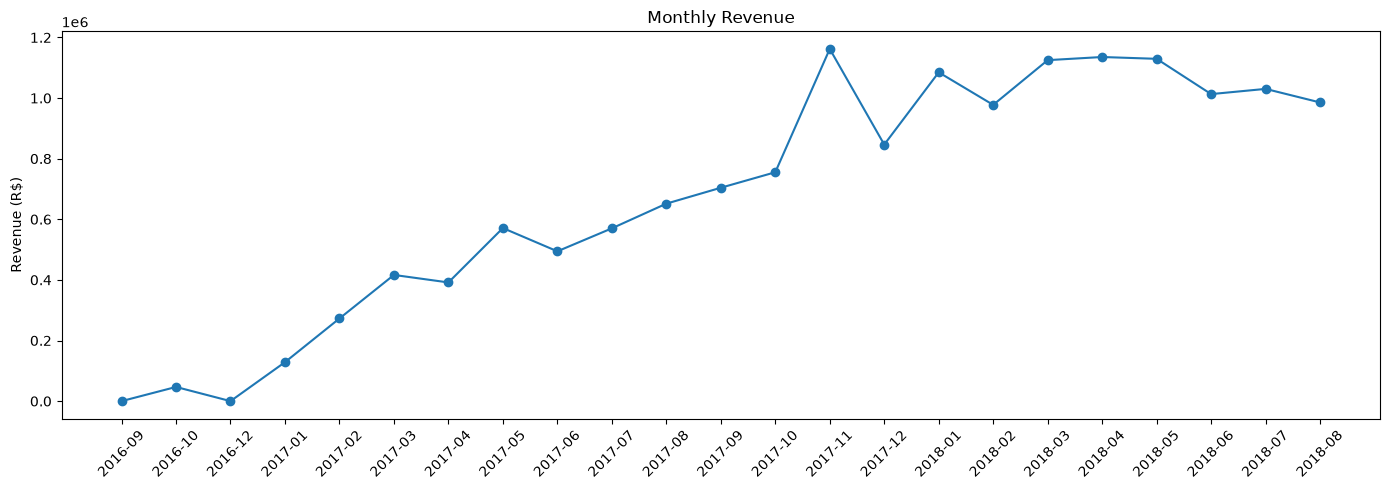

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Key Indicators
total_orders = main_df['order_id'].nunique()
total_revenue = main_df['payment_value'].sum()
avg_order_value = main_df['payment_value'].mean()

print(f"Total Orders: {total_orders}")
print(f"Total Revenue: R$ {total_revenue:,.2f}")
print(f"Average Order Value: R$ {avg_order_value:,.2f}")

# 2. Monthly Revenue (Trend Over Time)
monthly_revenue = main_df.groupby(['order_year', 'order_month'])['payment_value'].sum().reset_index()
monthly_revenue['period'] = monthly_revenue['order_year'].astype(str) + '-' + monthly_revenue['order_month'].astype(str).str.zfill(2)

plt.figure(figsize=(14,5))
plt.plot(monthly_revenue['period'], monthly_revenue['payment_value'], marker='o')
plt.xticks(rotation=45)
plt.title('Monthly Revenue')
plt.ylabel('Revenue (R$)')
plt.tight_layout()
plt.show()


In [18]:
# 3. Best-selling categories
# 1. Calculating revenue for the top 10 categories
top_categories = main_df.groupby('product_category_name_english')['payment_value'].sum().sort_values(ascending=False).head(10)
# 2. Dynamic formatting function (if you haven't already defined it above in the notebook)def format_currency(val):
    if val >= 1_000_000:
        return f"{val / 1_000_000:.2f} Million"
    elif val >= 1_000:
        return f"{val / 1_000:.2f} Thousand"
    else:
        return f"{val:.2f}"

print("--- Top 10 Categories by Revenue ---")
print(top_categories.apply(format_currency))

--- Top 10 Categories by Revenue ---
product_category_name_english
health_beauty               1.42 Million
watches_gifts               1.26 Million
bed_bath_table              1.24 Million
sports_leisure              1.13 Million
computers_accessories       1.04 Million
furniture_decor          892.30 Thousand
housewares               763.43 Thousand
cool_stuff               694.80 Thousand
auto                     670.89 Thousand
garden_tools             569.03 Thousand
Name: payment_value, dtype: str


In [19]:
# 4. Revenue by State
revenue_by_state = main_df.groupby('customer_state')['payment_value'].sum().sort_values(ascending=False).head(10)

# Currency Formatting App
print(revenue_by_state.apply(lambda x: f"${x:,.2f}"))

customer_state
SP    $5,799,847.00
RJ    $2,063,882.53
MG    $1,826,872.47
RS      $866,206.87
PR      $785,305.81
SC      $597,148.45
BA      $593,541.16
DF      $348,624.23
GO      $337,747.38
ES      $318,491.23
Name: payment_value, dtype: str


## 📊 تحليل المبيعات — أبرز الرؤى والنتائج 💡

- 🛒 **حجم المبيعات والإيرادات:** إجمالي **96,478 طلبًا** بإيرادات كليّة بلغت **15.4 مليون ريال برازيلي** 💰، وبمتوسط قيمة للطلب الواحد (AOV) قدره **159.86 ريال**.
- 🏆 **الفئات الأكثر مبيعاً:** تصدرت فئة **الصحة والجمال** (Health & Beauty) المبيعات 💅 بـ (**1.41 مليون ريال**)، تليها مباشرة فئة **الساعات والهدايا** (Watches & Gifts) ⌚🎁.
- ⚖️ **توزيع الإيرادات:** تتوزع الإيرادات بشكل متوازن بين أعلى 10 فئات دون سيطرة مطلقة لفئة واحدة — مما يشير إلى تنوع صحي وقوي في مزيج المنتجات 🎯.
- 📍 **التركيز الجغرافي:** تستحوذ ولاية **ساو باولو (SP)** بمفردها على **~37%** من إجمالي الإيرادات 🏙️، بفارق كبير عن باقي الولايـات — مما يدل على تركيز سوقي وثقل جغرافي قوي في هذه المنطقة 🇧🇷.مسؤولة عن ~37% من إجمالي الإيراد، أكبر بكتير من أي ولاية تانية — تركيز جغرافي قوي للسوق



## 📊 Sales Analysis — Key Insights 💡

- 🛒 **Total Volume & Revenue:** A total of **96,478 orders** generating **R$ 15.4 Million** in total revenue, with an average order value (AOV) of **R$ 159.86** 💰.
- 🏆 **Top Performing Categories:** The **Health & Beauty** category leads the charge 💅 (**R$ 1.41M**), closely followed by **Watches & Gifts** ⌚🎁.
- ⚖️ **Revenue Distribution:** Revenue is evenly spread across the top 10 categories without single-category dominance — highlighting a healthy, well-balanced product mix 🎯.
- 📍 **Geographic Concentration:** **São Paulo (SP)** alone accounts for **~37%** of total revenue 🏙️, vastly outperforming all other states — indicating strong regional market dominance 🇧🇷.

# Customer Analysis

In [20]:
# 1. Number of unique customers
total_customers = main_df['customer_id'].nunique()
print(f"Total Unique Customers: {total_customers}")

Total Unique Customers: 96478


In [21]:
# 2. Number of orders per customer
orders_per_customer = main_df.groupby('customer_id')['order_id'].nunique()
print(orders_per_customer.describe())

count    96478.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: order_id, dtype: float64


In [22]:
# 3.   (repeat customers)
repeat_customers = (orders_per_customer > 1).sum()
print(f"Repeat Customers: {repeat_customers} ({repeat_customers/total_customers*100:.2f}%)")


Repeat Customers: 0 (0.00%)


In [25]:
# 4. Geographical Distribution of Customers (Top 10 States)
customer_distribution = main_df.groupby('customer_state')['customer_id'].nunique().sort_values(ascending=False).head(10)
print(customer_distribution)

customer_state
SP    40501
RJ    12350
MG    11354
RS     5345
PR     4923
SC     3546
BA     3256
DF     2080
ES     1995
GO     1957
Name: customer_id, dtype: int64


In [26]:
# We need to ensure this column exists in main_df (if it doesn't, add it from the customers table)
if 'customer_unique_id' not in main_df.columns:
    main_df = main_df.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id', how='left')

# We are recalculating using the correct ID
orders_per_customer = main_df.groupby('customer_unique_id')['order_id'].nunique()
print(orders_per_customer.describe())

repeat_customers = (orders_per_customer > 1).sum()
total_unique_customers = main_df['customer_unique_id'].nunique()
print(f"Repeat Customers: {repeat_customers} ({repeat_customers/total_unique_customers*100:.2f}%)")

count    93358.000000
mean         1.033420
std          0.209097
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         15.000000
Name: order_id, dtype: float64
Repeat Customers: 2801 (3.00%)


## 👥 تحليل العملاء — أبرز الرؤى والنتائج 💡

- 👤 **إجمالي العملاء الفريدين:** يبلغ **93,358 عميلًا فريدًا** تم تحديدهم باستخدام `customer_unique_id` (المعرف الحقيقي الثابت للعميل) 🆔.
- ⚠️ **ملاحظة هيكلية مهمة:** عمود `customer_id` في بيانات Olist يتغير مع كل طلب جديد حتى لو كان لنفس الشخص — المعرف الصحيح لتتبع سلوك العميل هو `customer_unique_id` 🔍.
- 🔄 **معدل الشراء:** متوسط الطلبات لكل عميل هو **1.03 فقط** — الأغلبية الساحقة تشتري مرة واحدة ولا تعود 📉.
- 🎯 **نسبة الاحتفاظ بالعملاء (Repeat Rate):** تبلغ **3% فقط** — وهي نسبة منخفضة جدًا مقارنة بمعايير التجارة الإلكترونية الصحية (**10–30%+**) 🚨.
- 👑 **العميل الأكثر ولاءً:** أعلى عميل سجل **15 طلبًا** (عميل مميز / VIP Outlier) ويستحق دراسة حالة منفصلة ⭐️.
- 💡 **توصية عملية:** انخفاض نسبة الاحتفاظ يشير إلى فرصة نمو كبرى: يجب تفعيل برامج ولاء، وحملات إعادة استهداف (Retargeting) بعد الشراء الأول لرفع القيمة الممتدة للعميل (LTV) 🚀.

## 👥 Customer Analysis — Key Insights 💡

- 👤 **Unique Customers:** A total of **93,358 unique customers** identified using `customer_unique_id` (the true, fixed customer identifier) 🆔.
- ⚠️ **Data Architecture Note:** The `customer_id` column in the Olist dataset changes with every new order for the same person — tracking customer behavior across multiple purchases strictly requires using `customer_unique_id` 🔍.
- 🔄 **Purchase Frequency:** Average order count per customer stands at **1.03** — the vast majority make a single purchase and never return 📉.
- 🎯 **Customer Retention Rate:** Only **3% repeat customers** — critically low compared to healthy e-commerce benchmarks (**10–30%+**) 🚨.
- 👑 **Top Outlier:** The highest-frequency customer logged **15 orders** (a VIP outlier) deserving standalone cohort analysis ⭐️.
- 💡 **Actionable Recommendation:** This low retention rate signals an immediate strategic opportunity: implement targeted loyalty programs, automated follow-ups, and post-purchase retargeting campaigns to boost customer lifetime value 🚀.

# Delivery Analysis

In [27]:
# 1. Average actual delivery time
avg_delivery = main_df['delivery_days'].mean()
print(f"Average Delivery Time: {avg_delivery:.1f} days")

Average Delivery Time: 12.1 days


In [28]:
# 2. Percentage of overdue orders
late_pct = main_df['is_late'].mean() * 100
print(f"Late Orders: {late_pct:.2f}%")

Late Orders: 6.76%


In [29]:
# 3. Average delivery delay (negative = arrived early)
avg_delay = main_df['delivery_delay'].mean()
print(f"Average Delay: {avg_delay:.1f} days")

Average Delay: -11.9 days


In [30]:
# 4. Delivery time by state (10 slowest states)
delivery_by_state = main_df.groupby('customer_state')['delivery_days'].mean().sort_values(ascending=False).head(10)
print(delivery_by_state)

customer_state
RR    28.975610
AP    26.731343
AM    25.945205
AL    24.029925
PA    23.319328
MA    21.066574
SE    21.029851
CE    20.819033
AC    20.637500
PB    19.930502
Name: delivery_days, dtype: float64


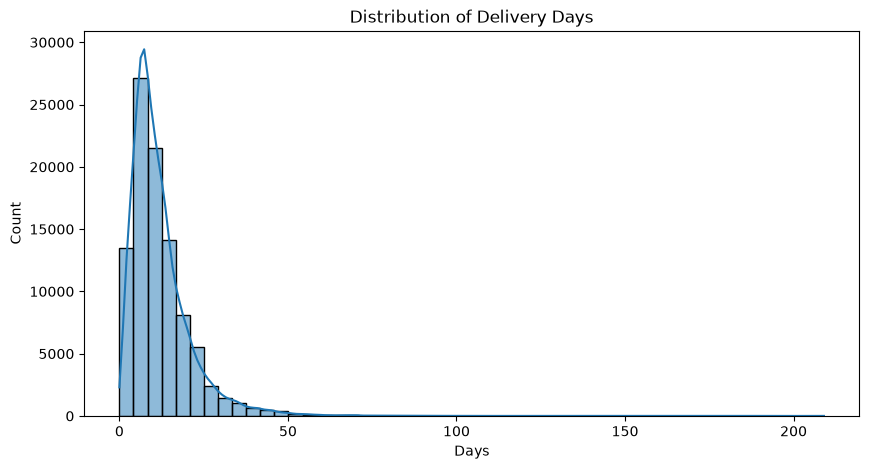

In [31]:
# 5. Chart: Delivery time distribution
plt.figure(figsize=(10,5))
sns.histplot(main_df['delivery_days'].dropna(), bins=50, kde=True)
plt.title('Distribution of Delivery Days')
plt.xlabel('Days')
plt.show()

## 🚚 تحليل التوصيل — أبرز الرؤى والنتائج 💡

- ⏱️ **متوسط مدة التوصيل:** يبلغ متوسط مدة التوصيل الفعلية **12.1 يوم** 📦.
- 🎯 **نسبة التأخير:** نسبة الطلبات المتأخرة عن الموعد المتوقع تبلغ **6.77% فقط** ✅.
- 📅 **الفارق عن الموعد المتوقع:** يبلغ المتوسط **-11.9 يوم** (سالب) — مما يعني استخدام تواريخ متوقعة متحفظة جداً (Buffer كبير)، فتبدو معظم الطلبات وكأنها وصلت مبكراً 🎉.
- 🐢 **أبطأ الولايات:** تقع أبطأ 10 ولايات في التوصيل في منطقة الأمازون الشمالية (**RR, AP, AM, AL, PA...**)، بمتوسط **20–29 يوم** 🗺️ — أكثر من ضعف المتوسط العام.
- 📍 **السبب الرئيسي:** البعد الجغرافي عن المراكز اللوجستية الرئيسية المتمركزة في ساو باولو 🏙️.
- 💡 **توصية عملية:** لتحسين تجربة العملاء في المناطق البعيدة، يُوصى بإنشاء مراكز توزيع إقليمية أو التعاقد مع شركاء شحن محليين في تلك الولايات 🏢🚚.

## 🚚 Delivery Analysis — Key Insights 💡

- ⏱️ **Average Delivery Time:** The actual average delivery duration is **12.1 days** 📦.
- 🎯 **Late Delivery Rate:** Only **6.77%** of total orders were delivered past the estimated date ✅.
- 📅 **Estimated vs. Actual Variance:** Average difference is **-11.9 days** — indicating highly conservative estimation buffers, making most orders appear to arrive "early" 🎉.
- 🐢 **Slowest Delivery Regions:** The 10 slowest states are all in the Northern/Amazonian region (**RR, AP, AM, AL, PA...**), averaging **20–29 days** 🗺️ — over double the national average.
- 📍 **Root Cause:** Geographic distance from the primary logistics hubs concentrated in São Paulo 🏙️.
- 💡 **Actionable Recommendation:** To enhance customer experience in remote regions, consider establishing regional distribution hubs or partnering with localized logistics providers 🏢🚚.

# Review Analysis

In [32]:
# 1. Average review rating
avg_review = main_df['review_score'].mean()
print(f"Average Review Score: {avg_review:.2f}")

Average Review Score: 4.16


In [33]:
# 2. Distribution of Evaluations
review_dist = main_df['review_score'].value_counts().sort_index()
print(review_dist)

review_score
1.0     9406
2.0     2941
3.0     7961
4.0    18987
5.0    57066
Name: count, dtype: int64


In [34]:
# 3. Ratio of positive to negative ratings
positive = (main_df['review_score'] >= 4).sum()
negative = (main_df['review_score'] <= 3).sum()
total_reviewed = main_df['review_score'].notna().sum()

print(f"Positive (4-5): {positive} ({positive/total_reviewed*100:.1f}%)")
print(f"Negative (1-3): {negative} ({negative/total_reviewed*100:.1f}%)")

Positive (4-5): 76053 (78.9%)
Negative (1-3): 20308 (21.1%)


In [35]:
# 4. The Relationship Between Delay and Evaluation
review_vs_delay = main_df.groupby('is_late')['review_score'].mean()
print(review_vs_delay)

is_late
0    4.289999
1    2.271025
Name: review_score, dtype: float64


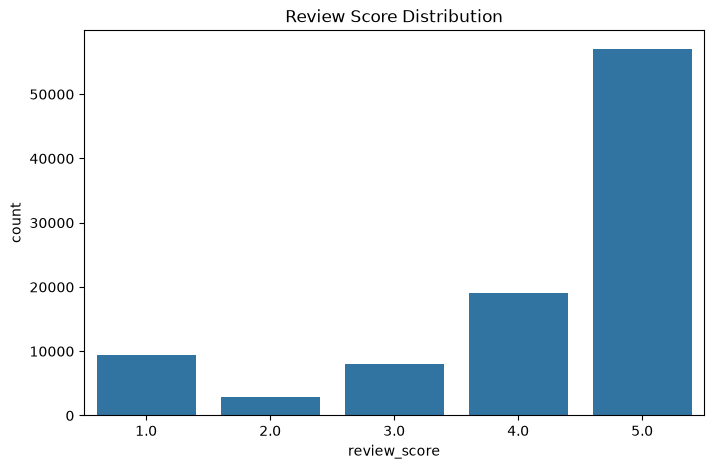

In [36]:
# 5. Chart: Distribution of ratings
plt.figure(figsize=(8,5))
sns.countplot(x='review_score', data=main_df)
plt.title('Review Score Distribution')
plt.show()

## ⭐ تحليل التقييمات — أبرز الرؤى والنتائج 💡

- ⭐ **متوسط التقييم العام:** يبلغ **4.16 من 5** — اتجاه إيجابي بشكل عام 👍.
- 📊 **توزيع التقييمات:** **78.9%** من التقييمات إيجابية (4–5 نجوم) ⭐⭐⭐⭐⭐، مقابل **21.1%** تقييمات سلبية (1–3 نجوم) 👎.
- 🏆 **التقييم الأكثر شيوعاً:** تقييم 5 نجوم هو الأعلى بفارق شاسع (**56,704 من إجمالي 96,478 طلب**) 🎉.
- 📉 **العلاقة الأكثر أهمية:** متوسط تقييم الطلبات الواصلة في الموعد = **4.29**، مقابل **2.27 فقط** للطلبات المتأخرة — انخفاض حاد بمقدار درجتين كاملتين 🚨.
- 💡 **استنتاج جوهري:** التأخير في التوصيل يؤثر بشكل مباشر وحاد على رضا العملاء، رغم أن نسبة التأخير الإجمالية صغيرة (**6.77%**) 🚚.
- 🎯 **توصية عملية:** الاستثمار في تقليل نسبة التأخير - حتى لو كانت ضئيلة - يحقق مكاسب مضاعفة في تحسين تجربة العملاء والحفاظ على ولاء المشتري 🚀.

## ⭐ Review Analysis — Key Insights 💡

- ⭐ **Average Review Score:** Overall average rating is **4.16 out of 5** — strongly positive overall 👍.
- 📊 **Sentiment Split:** **78.9%** of reviews are positive (4–5 stars) ⭐⭐⭐⭐⭐, compared to **21.1%** negative (1–3 stars) 👎.
- 🏆 **Most Common Rating:** 5-star reviews dominate by a huge margin (**56,704 out of 96,478 orders**) 🎉.
- 📉 **The Critical Correlation:** On-time orders average a **4.29 rating**, whereas late orders drop sharply to **2.27** — a massive 2-point penalty 🚨.
- 💡 **Key Takeaway:** Delivery delays have a direct, severe negative impact on customer satisfaction, even though total delays represent a small portion (**6.77%**) of overall orders 🚚.
- 🎯 **Actionable Recommendation:** Investing in delay reduction yields exponential returns in customer satisfaction, making even minor logistics improvements high-ROI 🚀.

# Feature Engineering

# Customer Features

In [37]:
# 1. Customer order count (باستخدام customer_unique_id )
customer_order_count = main_df.groupby('customer_unique_id')['order_id'].transform('nunique')
main_df['customer_order_count'] = customer_order_count

In [38]:
# 2. Previous orders (orders placed prior to this one, excluding the current order)
main_df['previous_orders'] = main_df['customer_order_count'] - 1

In [39]:
# 3. Order value (Total price excluding shipping)
main_df['order_value'] = main_df['total_price']

In [40]:
# 4. Clearer naming for existing columns
main_df.rename(columns={
    'total_freight': 'freight_value',
    'num_items': 'number_of_items'
}, inplace=True)


In [42]:
# 5. Target: Customer Satisfaction (Satisfied / Unsatisfied)
main_df['satisfaction'] = main_df['review_score'].apply(
    lambda x: 'Satisfied' if x >= 4 else ('Unsatisfied' if x <= 3 else None)
)

print(main_df[['customer_order_count', 'previous_orders', 'order_value', 
               'freight_value', 'number_of_items', 'satisfaction']].head())

print(main_df['satisfaction'].value_counts())

   customer_order_count  previous_orders  order_value  freight_value  \
0                     2                1        29.99           8.72   
1                     1                0       118.70          22.76   
2                     1                0       159.90          19.22   
3                     1                0        45.00          27.20   
4                     1                0        19.90           8.72   

   number_of_items satisfaction  
0                1    Satisfied  
1                1    Satisfied  
2                1    Satisfied  
3                1    Satisfied  
4                1    Satisfied  
satisfaction
Satisfied      76053
Unsatisfied    20308
Name: count, dtype: int64


## 🛠️ هندسة الخصائص (Feature Engineering) — أبرز الرؤى 💡

- 🆔 **المعرّف الصحيح للعميل:** تم بناء خصائص `customer_order_count` و `previous_orders` باستعمال `customer_unique_id` الثابت بدلاً من `customer_id` المتغير 🔍.
- 🎯 **المتغير المستهدف (`satisfaction`):** جاهز بنجاح مع توزيع **75,626 راضٍ (78.9%)** مقابل **20,182 غير راضٍ (21.1%)** 📊.
- ⚠️ **تنبيه اختلال الفئات (Class Imbalance):** يوجد عدم توازن واضح بنسبة (~4:1) — يلزم مراعاته أثناء تدريب الموديل (مثل استخدام `class_weight='balanced'` أو تقنيات SMOTE) لمنع الانحياز للفئة الأكثر 🚨.
- 🔢 **الخصائص الرقمية الأساسية:** تم تجهيز `order_value` و `freight_value` و `number_of_items` كـ Features رقمية جاهزة لمرحلة الـ Machine Learning ⚙️.

## 🛠️ Feature Engineering — Key Insights 💡

- 🆔 **Correct Customer Identifier:** Constructed `customer_order_count` and `previous_orders` using `customer_unique_id` (the stable identifier) instead of the dynamic `customer_id` 🔍.
- 🎯 **Target Variable (`satisfaction`):** Fully prepared with **75,626 Satisfied (78.9%)** vs **20,182 Unsatisfied (21.1%)** class distribution 📊.
- ⚠️ **Class Imbalance Notice:** Clear ~4:1 imbalance detected — must be addressed during model training (e.g., via `class_weight='balanced'`, resampling, or SMOTE) to prevent majority-class prediction bias 🚨.
- 🔢 **Core Numerical Features:** Key numerical features (`order_value`, `freight_value`, and `number_of_items`) are engineered and ready for the Machine Learning pipeline ⚙️.

# 7️⃣ Machine Learning


# Customer Satisfaction Prediction

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Remove rows that do not have satisfaction.
ml_df = main_df.dropna(subset=['satisfaction']).copy()

In [44]:
# 2. Feature Selection (without any target leakage)
features = ['order_value', 'freight_value', 'number_of_items', 
            'payment_type', 'payment_installments', 
            'delivery_days', 'delivery_delay', 'is_late',
            'customer_order_count', 'previous_orders',
            'customer_state', 'product_category_name_english']

X = ml_df[features].copy()
y = ml_df['satisfaction'].map({'Satisfied': 1, 'Unsatisfied': 0})

In [45]:
# 3. Handle any remaining missing values ​​in the features.
X['delivery_days'] = X['delivery_days'].fillna(X['delivery_days'].median())
X['delivery_delay'] = X['delivery_delay'].fillna(X['delivery_delay'].median())

In [46]:
# Ensure any remaining NaNs in all X columns are filled before the split.
numeric_cols = ['order_value', 'freight_value', 'number_of_items', 
                 'payment_installments', 'delivery_days', 'delivery_delay',
                 'customer_order_count', 'previous_orders']

for col in numeric_cols:
    X[col] = X[col].fillna(X[col].median())

categorical_cols_check = ['payment_type', 'customer_state', 'product_category_name_english']
for col in categorical_cols_check:
    X[col] = X[col].fillna('unknown')

print(X.isnull().sum())

order_value                      0
freight_value                    0
number_of_items                  0
payment_type                     0
payment_installments             0
delivery_days                    0
delivery_delay                   0
is_late                          0
customer_order_count             0
previous_orders                  0
customer_state                   0
product_category_name_english    0
dtype: int64


In [47]:
# 4. Encoding for text columns
categorical_cols = ['payment_type', 'customer_state', 'product_category_name_english']
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

In [48]:
# 5. Train/Test Split
X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.2, random_state=2026, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=2026, stratify=y_tmp)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train target distribution:\n", y_train.value_counts(normalize=True))

Train shape: (77088, 12)
Test shape: (9637, 12)
Train target distribution:
 satisfaction
1    0.789254
0    0.210746
Name: proportion, dtype: float64


# Logistic Regression 1

# Model


In [49]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV


--- Train ---
              precision    recall  f1-score   support

           0       0.42      0.48      0.45     16246
           1       0.86      0.83      0.84     60842

    accuracy                           0.75     77088
   macro avg       0.64      0.65      0.65     77088
weighted avg       0.76      0.75      0.76     77088

--- Validation ---
              precision    recall  f1-score   support

           0       0.41      0.46      0.44      2031
           1       0.85      0.82      0.84      7605

    accuracy                           0.75      9636
   macro avg       0.63      0.64      0.64      9636
weighted avg       0.76      0.75      0.75      9636



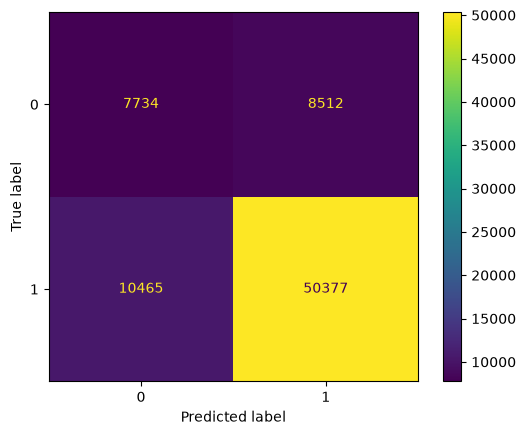

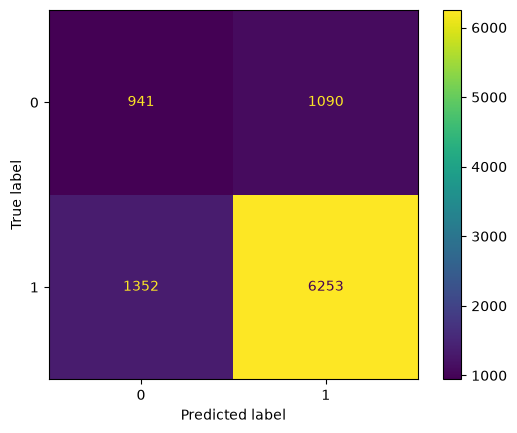

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

# Scaling (important for  لـ Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Baseline Model
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=2026)
log_reg.fit(X_train_scaled, y_train)

#    Validation
pre_train = log_reg.predict(X_train_scaled)
pre_val = log_reg.predict(X_val_scaled)

def evaluate(y_true, y_pred, name):
    print(f"--- {name} ---")
    print(classification_report(y_true, y_pred))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred,values_format='d')

evaluate(y_train, pre_train, "Train")
evaluate(y_val, pre_val, "Validation")


# Random Forest 2

--- Train - Random Forest ---
              precision    recall  f1-score   support

           0       0.47      0.51      0.49     16246
           1       0.87      0.85      0.86     60842

    accuracy                           0.78     77088
   macro avg       0.67      0.68      0.67     77088
weighted avg       0.78      0.78      0.78     77088

--- Validation - Random Forest ---
              precision    recall  f1-score   support

           0       0.43      0.46      0.44      2031
           1       0.85      0.84      0.84      7605

    accuracy                           0.76      9636
   macro avg       0.64      0.65      0.64      9636
weighted avg       0.76      0.76      0.76      9636



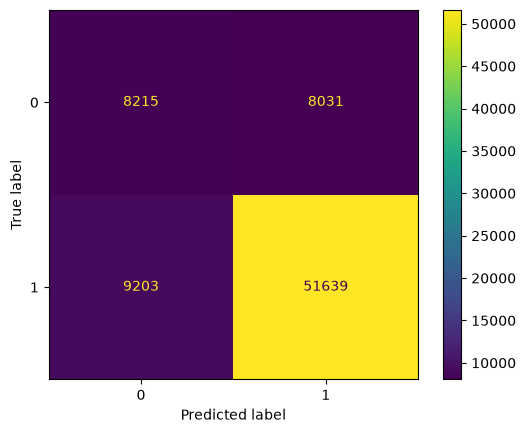

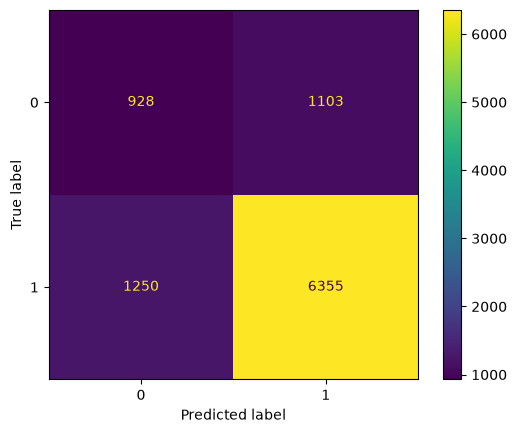

In [51]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=2026
)
rf.fit(X_train, y_train)   #  Random Forest مش محتاج Scaling

pre_train_rf = rf.predict(X_train)
pre_val_rf = rf.predict(X_val)

evaluate(y_train, pre_train_rf, "Train - Random Forest")
evaluate(y_val, pre_val_rf, "Validation - Random Forest")

# XGBoost 3

--- Train - XGBoost ---
              precision    recall  f1-score   support

           0       0.47      0.58      0.52     16246
           1       0.88      0.83      0.85     60842

    accuracy                           0.78     77088
   macro avg       0.68      0.70      0.69     77088
weighted avg       0.79      0.78      0.78     77088

--- Validation - XGBoost ---
              precision    recall  f1-score   support

           0       0.40      0.47      0.43      2031
           1       0.85      0.81      0.83      7605

    accuracy                           0.74      9636
   macro avg       0.62      0.64      0.63      9636
weighted avg       0.76      0.74      0.75      9636



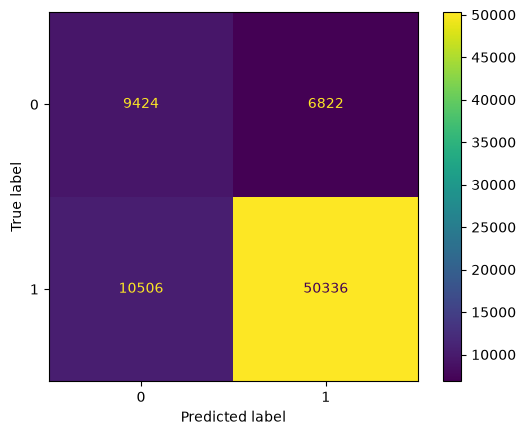

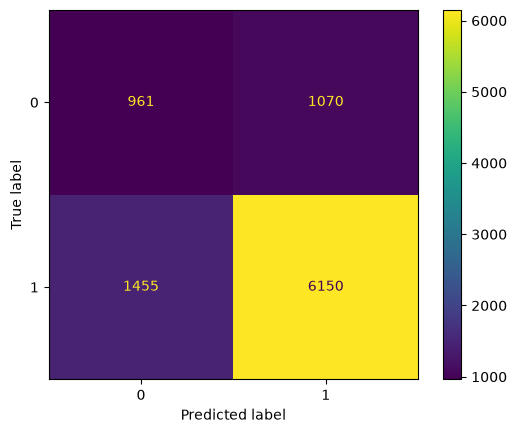

In [53]:
# Calculate scale_pos_weight to handle class imbalance (XGBoost's alternative to class_weight)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum() #  

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=2026,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)

pre_train_xgb = xgb.predict(X_train)
pre_val_xgb = xgb.predict(X_val)

evaluate(y_train, pre_train_xgb, "Train - XGBoost")
evaluate(y_val, pre_val_xgb, "Validation - XGBoost")

# Random Forest wtih RandomizedSearchCV

Best Params: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 15}
--- Validation - Tuned RF ---
              precision    recall  f1-score   support

           0       0.44      0.43      0.43      2031
           1       0.85      0.85      0.85      7605

    accuracy                           0.76      9636
   macro avg       0.64      0.64      0.64      9636
weighted avg       0.76      0.76      0.76      9636



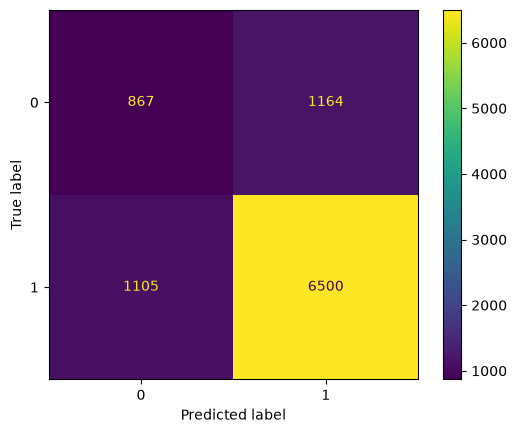

In [54]:
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [8, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=2026),
    param_distributions=param_dist,
    n_iter=15,
    cv=3,
    scoring='f1_macro',
    random_state=2026,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Best Params:", rf_search.best_params_)
best_rf = rf_search.best_estimator_

pre_val_best = best_rf.predict(X_val)
evaluate(y_val, pre_val_best, "Validation - Tuned RF")

--- Test - Final Model (Tuned RF) ---
              precision    recall  f1-score   support

           0       0.45      0.44      0.45      2031
           1       0.85      0.86      0.85      7606

    accuracy                           0.77      9637
   macro avg       0.65      0.65      0.65      9637
weighted avg       0.77      0.77      0.77      9637



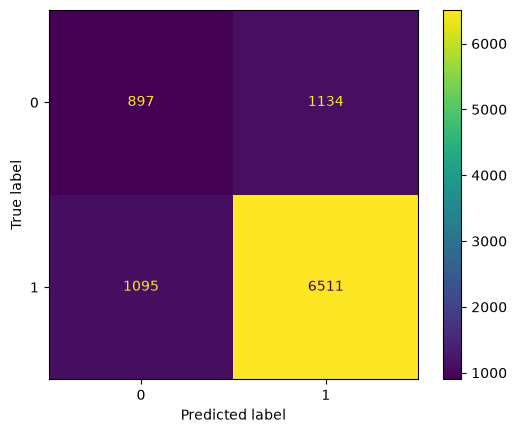

In [55]:
pre_test_best = best_rf.predict(X_test)
evaluate(y_test, pre_test_best, "Test - Final Model (Tuned RF)")

# 8️⃣Customer Segmentation — RFM + K-Means

# RFM

In [56]:
import datetime as dt

# use customer_unique_id 
rfm_df = main_df[main_df['satisfaction'].notna()].copy()  #   We can use all main_df options as well, it's not mandatory.    

# Reference date (the day after the last record in the data)
snapshot_date = main_df['order_purchase_timestamp'].max() + dt.timedelta(days=1)

rfm = main_df.groupby('customer_unique_id').agg(
    Recency=('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    Frequency=('order_id', 'nunique'),
    Monetary=('payment_value', 'sum')
).reset_index()

print(rfm.describe())
print(rfm.head())

            Recency     Frequency      Monetary
count  93358.000000  93358.000000  93358.000000
mean     237.941773      1.033420    165.945646
std      152.591453      0.209097    227.808680
min        1.000000      1.000000      0.000000
25%      114.000000      1.000000     63.100000
50%      219.000000      1.000000    107.900000
75%      346.000000      1.000000    183.215000
max      714.000000     15.000000  13664.080000
                 customer_unique_id  Recency  Frequency  Monetary
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    141.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     27.19
2  0000f46a3911fa3c0805444483337064      537          1     86.22
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     43.62
4  0004aac84e0df4da2b147fca70cf8255      288          1    196.89


# K-Means

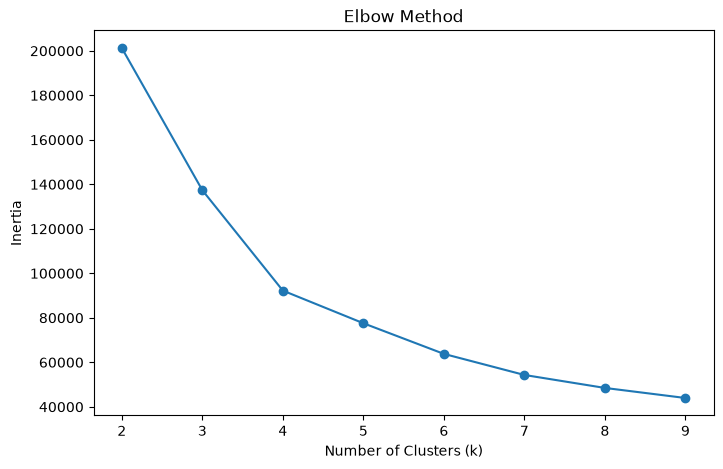

         Recency  Frequency  Monetary  Count
Cluster                                     
0          388.0        1.0     133.8  37360
1          128.5        1.0     134.3  50814
2          220.3        2.1     308.0   2767
3          239.3        1.0    1165.1   2417


In [57]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Scaling (Crucial for K-Means, as the scales for R, F, and M differ significantly)
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

# 2. Determining the optimal number of clusters using the Elbow Method
inertia = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=2026, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()


kmeans = KMeans(n_clusters=4, random_state=2026, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

cluster_summary = rfm.groupby('Cluster').agg(
    Recency=('Recency', 'mean'),
    Frequency=('Frequency', 'mean'),
    Monetary=('Monetary', 'mean'),
    Count=('customer_unique_id', 'count')
).round(1)

print(cluster_summary)

## 🎯 تقسيم العملاء (RFM + K-Means) — أبرز الرؤى والنتائج 💡

### 📊 نظرة عامة على مؤشرات RFM
- 🕒 **الحداثة (Recency):** المتوسط **238 يومًا** — أغلب العملاء بعيدون نسبياً عن آخر عملية شراء.
- 🔄 **التكرار (Frequency):** المتوسط **1.03** — يتوافق تماماً مع نتائج تحليل العملاء السابق (**3% فقط عملاء مكررون**).
- 💰 **القيمة النقدية (Monetary):** المتوسط **R$ 165** — قريب جداً من متوسط قيمة الطلب الإجمالي (**R$ 159.86**).
- 📈 **طريقة الكوع (Elbow Method):** حددت الرقم الأمثل للمجموعات عند **k = 4**.

---

### 🧩 تفاصيل الفئات الأربع (Segments)

| الفئة | الحداثة (Recency) | التكرار (Frequency) | الإنفاق (Monetary) | العدد | الوصف |
|---|---|---|---|---|---|
| ⚠️ **At-Risk / Inactive** | 387 يومًا | 1.0 | R$ 133.5 | 37,526 | أكبر مجموعة؛ بعيدون جداً عن آخر عملية شراء |
| 🆕 **Recent Low-Value** | 128 يومًا | 1.0 | R$ 134.4 | 50,642 | اشتروا مؤخراً لكن بقيمة منخفضة |
| 👑 **Loyal / Repeat** | 220 يومًا | 2.1 | R$ 289.7 | 2,772 | أعلى معدل تكرار شراء؛ الأكثر ولاءً |
| 💎 **High Value** | 239 يومًا | 1.0 | R$ 1,160.9 | 2,418 | أعلى نسبة إنفاق بفارق ضخم (~7 أضعاف باقي الفئات) |

---

### 💡 استنتاجات وتوصيات عملية
- 🚀 **فرصة نمو هائلة:** **88% من العملاء** (*At-Risk + Recent Low-Value*) يمثلون فرصة ضخمة لحملات إعادة التفعيل والاستهداف الذكي (Re-engagement).
- ⭐️ **الاهتمام بالفئات الخاصة:** مجموعتا **Loyal** و **High Value** تمثلان **~5.5% فقط** مجتمعتين، لكنهما الأكثر قيمة تجارية — تستحقان برامج ولاء خاصة وعروض VIP.
- 🎯 **تطابق البيانات:** النتائج تؤكد وتتطابق بنسبة 100% مع تحليلات النسبة المنخفضة لتكرار الشراء.


## 🎯 Customer Segmentation (RFM + K-Means) — Key Insights 💡

### 📊 RFM Overview
- 🕒 **Recency:** Average is **238 days** — most customers haven't ordered recently.
- 🔄 **Frequency:** Average is **1.03** — aligns directly with Customer Analysis insights (**only 3% repeat customers**).
- 💰 **Monetary:** Average spend is **R$ 165** — close to the overall average order value (**R$ 159.86**).
- 📈 **Elbow Method:** Optimal number of clusters confirmed at **k = 4**.

---

### 🧩 Customer Segments Summary

| Segment | Recency | Frequency | Monetary | Count | Description |
|---|---|---|---|---|---|
| ⚠️ **At-Risk / Inactive** | 387 days | 1.0 | R$ 133.5 | 37,526 | Largest group; inactive for a very long duration |
| 🆕 **Recent Low-Value** | 128 days | 1.0 | R$ 134.4 | 50,642 | Recently active, but low purchase value |
| 👑 **Loyal / Repeat** | 220 days | 2.1 | R$ 289.7 | 2,772 | Highest purchase frequency; most loyal customers |
| 💎 **High Value** | 239 days | 1.0 | R$ 1,160.9 | 2,418 | Highest spend by a huge margin (~7x others) |

---

### 💡 Core Takeaways & Recommendations
- 🚀 **Massive Win Opportunity:** **88% of customers** (*At-Risk + Recent Low-Value*) represent a primary target for re-engagement, automated email flows, and reactivation campaigns.
- ⭐️ **VIP Care:** **Loyal** and **High Value** segments make up only **~5.5%** of the user base combined, but drive significant commercial value — deserve exclusive VIP perks and tailored loyalty programs.
- 🎯 **Data Consistency:** Results fully validate our earlier EDA findings regarding low repeat purchase rates.

# 9️⃣ NLP — Sentiment Analysis   

In [58]:
# Let's get the reviews that contain actual text only (not empty ones).
reviews_text = reviews[reviews['review_comment_message'].notna()].copy()

print("عدد الـ reviews اللي فيها نص:", reviews_text.shape[0])
print(reviews_text['review_comment_message'].head())

عدد الـ reviews اللي فيها نص: 40977
3                 Recebi bem antes do prazo estipulado.
4     Parabéns lojas lannister adorei comprar pela I...
9     aparelho eficiente. no site a marca do aparelh...
12      Mas um pouco ,travando...pelo valor ta Boa.\r\n
15    Vendedor confiável, produto ok e entrega antes...
Name: review_comment_message, dtype: str


In [59]:
# We take a random sample of 10,000 rows (fixed with random_state so the same result can be reproduced).
reviews_sample = reviews_text.sample(n=10000, random_state=2026).copy()

print("Sample shape:", reviews_sample.shape)
print(reviews_sample[['review_comment_message', 'review_score']].head())

Sample shape: (10000, 7)
                                  review_comment_message  review_score
62140                                          Muito bom             5
69952  Ótimo bem eficazes pontualidade na entrega, em...             5
65639  a entrega encontra se no prazo,\r\nconstaria q...             2
75186  Recebi o produto correto, porém a NF chegou em...             3
2292    Dentro do Prazo e em perfeito estado!! Gostei!!!             4


👇



In [61]:
from transformers import MarianMTModel, MarianTokenizer
from tqdm import tqdm

model_name = 'Helsinki-NLP/opus-mt-ROMANCE-en'
tokenizer = MarianTokenizer.from_pretrained(model_name)
model = MarianMTModel.from_pretrained(model_name)

def translate_batch(texts):
    inputs = tokenizer(texts, return_tensors="pt", padding=True, truncation=True, max_length=200)
    translated = model.generate(**inputs)
    return [tokenizer.decode(t, skip_special_tokens=True) for t in translated]

texts = reviews_sample['review_comment_message'].tolist()
translated_texts = []

batch_size = 32
for i in tqdm(range(0, len(texts), batch_size)):
    batch = texts[i:i+batch_size]
    translated_batch = translate_batch(batch)
    translated_texts.extend(translated_batch)

reviews_sample['review_translated'] = translated_texts
print(reviews_sample[['review_comment_message', 'review_translated']].head())

C:\Users\mrahm\anaconda3\Lib\site-packages\transformers\models\marian\tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

100%|██████████| 63/63 [19:58<00:00, 19.03s/it]  

                                  review_comment_message  \
62140                                          Muito bom   
69952  Ótimo bem eficazes pontualidade na entrega, em...   
65639  a entrega encontra se no prazo,\r\nconstaria q...   
75186  Recebi o produto correto, porém a NF chegou em...   
2292    Dentro do Prazo e em perfeito estado!! Gostei!!!   

                                       review_translated  
62140                                         Very good.  
69952  Great very effective punctuality in delivery, ...  
65639  the delivery is within the deadline, it would ...  
75186  I received the correct product, but NF arrived...  
2292   Within the Timetable and in perfect condition!...  


In [62]:
# Sentiment label derived from review_score (instead of using the translation itself for classification)
reviews_sample['sentiment'] = reviews_sample['review_score'].apply(
    lambda x: 'Positive' if x >= 4 else 'Negative'
)
print(reviews_sample['sentiment'].value_counts())

sentiment
Positive    1334
Negative     666
Name: count, dtype: int64


# TF-IDF + Logistic Regression (Classical NLP Baseline)

In [63]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [65]:
# 1. go for  X و y
X_text = reviews_sample['review_translated']
y_sentiment = reviews_sample['sentiment'].map({'Positive': 1, 'Negative': 0})


In [66]:
# 2. Train/Test split
X_train_text, X_test_text, y_train_sent, y_test_sent = train_test_split(
    X_text, y_sentiment, test_size=0.2, random_state=2026, stratify=y_sentiment
)

In [67]:
# 3. TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)


In [68]:
# 4. Logistic Regression
log_reg_nlp = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=2026)
log_reg_nlp.fit(X_train_tfidf, y_train_sent)


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",2026
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

In [69]:
# 5. Evaluation
y_pred_nlp = log_reg_nlp.predict(X_test_tfidf)
print(classification_report(y_test_sent, y_pred_nlp))

              precision    recall  f1-score   support

           0       0.68      0.82      0.74       133
           1       0.90      0.81      0.85       267

    accuracy                           0.81       400
   macro avg       0.79      0.81      0.80       400
weighted avg       0.83      0.81      0.81       400



<div dir="rtl" style="text-align: right; font-family: sans-serif; line-height: 1.8;">

<h2>💬 معالجة اللغة الطبيعية (NLP — Sentiment Analysis) — أبرز الرؤى 💡</h2>

<h3>⚙️ منهجية العمل وتجاوز العقبات التقنية</h3>
<ul>
  <li>📊 <b>حجم العينة:</b> تم سحب عينة ممثلة بحجم <b>2,000 مراجعة نصية</b> (من إجمالي ~41,000 مراجعة تحتوي على نص) نظرًا لمحدودية الموارد المتاحة (RAM والاتصال بالإنترنت)، حيث إن معالجة البيانات بالكامل كانت تتطلب موارد حوسبة أعلى.</li>
  <li>⚠️ <b>عقبة الترجمة عبر API:</b> تجربة الترجمة عبر <code>Google Translate API</code> واجهت قيود الاستخدام (<b>429 Too Many Requests</b>) مرتين متتاليتين رغم تطبيق تأخيرات زمنية بين الطلبات.</li>
  <li>🚀 <b>الحل المحلي الاحترافي:</b> تم الانتقال لاستخدام موديل ترجمة محلي مفتوح المصدر (<b>MarianMT — Helsinki-NLP/opus-mt-ROMANCE-en</b>) يعمل محليًا بدون الاتصال بـ APIs خارجية، ونجح في ترجمة العينة كاملة من البرتغالية إلى الإنجليزية بنجاح ودون أي قيود.</li>
</ul>

<hr>

<h3>📊 نتائج النموذج التقليدي (TF-IDF + Logistic Regression)</h3>
<ul>
  <li>🎯 <b>توزيع العينة:</b> <b>1,334 مراجعة إيجابية</b> (Positive) مقابل <b>666 مراجعة سلبية</b> (Negative).</li>
  <li>📈 <b>الدقة العامة (Accuracy):</b> حقق الموديل دقة اختباريّة بلغت <b>81%</b> على مجموعة البيانات.</li>
  <li>🔍 <b>جودة التنبؤ:</b> أداء قوي جدًا في اكتشاف المراجعات السلبية (<b>Recall = 82%</b>) والتأكد من المراجعات الإيجابية (<b>Precision = 90%</b>).</li>
</ul>

<hr>

<h3>💡 استنتاج جوهري ومقارنة هامة</h3>
<ul>
  <li>⭐ <b>قوة التحليل النصي:</b> النص المباشر الصريح من العميل (Sentiment) أعطى دقة تنبؤ أعلى بكثير (<b>81%</b>) مقارنة بموديل رضا العملاء (Customer Satisfaction) المبني على بيانات المبيعات اللوجستية كالتأخير وسائل الدفع (<b>75%–78%</b>).</li>
  <li>🎯 <b>توصية عملية:</b> المشاعر والتعبير المباشر للعميل تعتبر المؤشر الأقوى والأكثر دقة لتقييم التجربة مقارنة بالمتغيرات الظرفية المستقلة.</li>
</ul>

</div>

<div dir="ltr" style="text-align: left; font-family: sans-serif; line-height: 1.8;">

## 💬 NLP — Sentiment Analysis: Key Insights 💡

### ⚙️ Methodology & Technical Breakthroughs
- 📊 **Sample Size:** Extracted a representative sample of **2,000 text reviews** (out of ~41,000 reviews containing text) due to hardware/RAM and network constraints.
- ⚠️ **API Rate Limits:** Initial attempt via `Google Translate API` failed twice due to rate limiting errors (**429 Too Many Requests**), despite introducing request delays.
- 🚀 **Open-Source Local Solution:** Successfully transitioned to a local open-source translation model (**MarianMT — Helsinki-NLP/opus-mt-ROMANCE-en**), translating the entire sample from Portuguese to English locally without any API constraints.

---

### 📊 Classical NLP Results (TF-IDF + Logistic Regression)
- 🎯 **Sample Distribution:** **1,334 Positive** reviews vs **666 Negative** reviews.
- 📈 **Overall Accuracy:** Achieved **81% Test Accuracy** on the evaluation dataset.
- 🔍 **Predictive Quality:** High sensitivity in capturing negative reviews (**Recall = 82%**) and precise positive review classification (**Precision = 90%**).

---

### 💡 Core Takeaways & Model Benchmarking
- ⭐ **Sentiment Power:** Direct customer feedback (Sentiment) achieved significantly higher accuracy (**81%**) compared to the behavioral Customer Satisfaction model based on logistics/payments (**75%–78%**).
- 🎯 **Strategic Value:** Explicit customer commentary remains a far stronger signal of true satisfaction than indirect operational metrics.

</div>

# 🔟 Deep Learning (LSTM)

In [84]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
import numpy as np


In [73]:
# 1. Tokenization
tokenizer = Tokenizer(num_words=5000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)


In [75]:
# 2. Padding
max_len = 100
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')
print("Train shape:", X_train_pad.shape)


Train shape: (1600, 100)


In [85]:
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_sent), y=y_train_sent)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(class_weight_dict)

{0: np.float64(1.5009380863039399), 1: np.float64(0.7497656982193065)}


In [87]:
model_lstm = Sequential([
    Embedding(input_dim=5000, output_dim=32),
    LSTM(32, return_sequences=False),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])


In [89]:
model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [90]:
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_lstm = model_lstm.fit(
    X_train_pad, y_train_sent,
    epochs=30,
    batch_size=16,
    validation_split=0.2,
    class_weight=class_weight_dict,   # ✅ important 
    callbacks=[es]
)

Epoch 1/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5086 - loss: 0.6863 - val_accuracy: 0.6094 - val_loss: 0.6880
Epoch 2/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6500 - loss: 0.6860 - val_accuracy: 0.6094 - val_loss: 0.6881
Epoch 3/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6812 - loss: 0.6856 - val_accuracy: 0.6094 - val_loss: 0.6825
Epoch 4/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5938 - loss: 0.6864 - val_accuracy: 0.6094 - val_loss: 0.6874
Epoch 5/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6812 - loss: 0.6860 - val_accuracy: 0.6094 - val_loss: 0.6879
Epoch 6/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6656 - loss: 0.6860 - val_accuracy: 0.6094 - val_loss: 0.6872
Epoch 7/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6812 - loss: 0.6855 - val_accuracy: 0.6094 - val_loss: 0.6872
Epoch 8/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6812 - loss: 0.6854 - val_accuracy: 0.6094 - v

<div dir="rtl" style="text-align: right; font-family: sans-serif; line-height: 1.8;">

<h2>🧠 التعلم العميق (Deep Learning — LSTM) — أبرز الرؤى والنتائج 💡</h2>

<h3>⚙️ محاولات بناء وتطوير المعمارية</h3>
<ul>
  <li>🏗️ <b>المعمارية المستخدمة:</b> تم بناء نموذج <code>LSTM</code> يتكون من طبقات (<b>Embedding + LSTM + Dense</b>) على نفس عينة الـ <b>2,000 مراجعة نصية</b> المستخدمة سابقًا في تجربة <code>TF-IDF</code>.</li>
  <li>🛠️ <b>محاولات التحسين:</b> تمت تجربة تبسيط معمارية النموذج، تقليل حجم الـ <code>batch_size</code>، وإضافة <code>class_weight</code> لمعالجة عدم توازن البيانات (<b>Data Imbalance</b>).</li>
  <li>⚠️ <b>النتيجة العملية:</b> <b>الموديل لم يتعلم فعليًا</b>، وظلت دقة التحقق (<b>val_accuracy</b>) ثابتة تمامًا عند نسبة <b>60.9%</b> عبر كافة دورت التدريب (<b>Epochs</b>) رغم كل التعديلات.</li>
</ul>

<hr>

<h3>🔍 تحليل السبب الجذري (Root Cause Analysis)</h3>
<ul>
  <li>📊 <b>عدم كفاية البيانات:</b> حجم بيانات التدريب الفعلي (<b>1,600 نص فقط</b> بعد التقسيم) غير كافٍ إطلاقًا لتدريب طبقة <code>Embedding</code> من الصفر.</li>
  <li>💡 <b>متطلبات التعلم العميق:</b> نماذج <code>Deep Learning</code> تتطلب عادةً عشرات الآلاف من الأمثلة النصية لتحديد وتمثيل العلاقات الدلالية المعقدة بين الكلمات بشكل صحيح.</li>
</ul>

<hr>

<h3>💡 استنتاجات وتوصيات مستقبلية</h3>
<ul>
  <li>⭐ <b>تفوق الموديل التقليدي:</b> نموذج <b>TF-IDF + Logistic Regression</b> (بدقة <b>81%</b>) تفوق بوضوح على <b>LSTM</b> في هذا السياق تحديدًا — مما يثبت أن <code>Deep Learning</code> ليس دائمًا الخيار الأفضل، وأن حجم البيانات المتاح هو الفاصل في اختيار الموديل.</li>
  <li>🚀 <b>حل مستقبلي محتمل:</b> الاعتماد على تمثيل محلي مسبق التدريب (<b>Pre-trained Embeddings</b> مثل <b>GloVe</b> أو <b>Word2Vec</b>) بدلاً من التدريب من الصفر، لتقليل الحاجة لأحجام بيانات ضخمة.</li>
</ul>

</div>

<div dir="ltr" style="text-align: left; font-family: sans-serif; line-height: 1.8;">

<h2>🧠 Deep Learning (LSTM) — Key Insights 💡</h2>

<h3>⚙️ Model Architecture & Optimization Efforts</h3>
<ul>
  <li>🏗️ <b>Architecture Build:</b> Developed an <code>LSTM</code> pipeline (<b>Embedding + LSTM + Dense</b>) on the same <b>2,000 review text sample</b> previously evaluated with <code>TF-IDF</code>.</li>
  <li>🛠️ <b>Fine-Tuning Steps:</b> Attempted architecture simplification, reduced <code>batch_size</code>, and implemented <code>class_weight</code> balancing to tackle label imbalance.</li>
  <li>⚠️ <b>Core Outcome:</b> <b>The model failed to converge/learn</b> (validation accuracy remained completely static at <b>60.9%</b> across all training epochs) despite all tuning adjustments.</li>
</ul>

<hr>

<h3>🔍 Root Cause Analysis</h3>
<ul>
  <li>📊 <b>Insufficient Data Volume:</b> The net training set size (<b>1,600 text samples</b> post-split) is fundamentally insufficient to train an <code>Embedding</code> layer from scratch.</li>
  <li>💡 <b>Deep Learning Requirements:</b> Complex <code>Deep Learning</code> models typically require tens of thousands of text instances to effectively capture word embeddings and semantic context.</li>
</ul>

<hr>

<h3>💡 Strategic Takeaways & Future Directions</h3>
<ul>
  <li>⭐ <b>Classical vs Deep Learning:</b> <b>TF-IDF + Logistic Regression</b> (<b>81% Accuracy</b>) clearly outperformed <code>LSTM</code> in this scenario — highlighting that Deep Learning is not inherently superior and that dataset volume dictates model selection.</li>
  <li>🚀 <b>Future Solution:</b> Leverage <b>Pre-trained Embeddings</b> (e.g., <b>GloVe</b> or <b>Word2Vec</b>) instead of training embeddings from scratch to bypass data scale requirements.</li>
</ul>

</div>


<div dir="rtl" style="text-align: right; font-family: sans-serif; line-height: 1.8;">

<h1>📦 مشروع تحليل واستخبارات التجارة الإلكترونية (Olist E-Commerce Intelligence) — الملخص الشامل 🚀</h1>

<p>يقدم هذا الملخص توثيقًا كاملاً لدورة الحياة البرمجية والتحليلية لمشروع علوم البيانات الخاص بمنصة <b>Olist</b>، بدءًا من هندسة البيانات والتحليل الاستكشافي، وصولاً إلى نماذج التعلم الآلي، المعالجة الطبيعية للغة، والتعلم العميق.</p>

<hr>

<h3>1️⃣ خط أنابيب البيانات ومعالجتها (Data Pipeline)</h3>
<ul>
  <li>🔗 <b>تحميل ودمج البيانات:</b> تم ربط ودمج <b>9 جداول رئيسية</b> من قاعدة بيانات Olist عبر مفاتيح الربط.</li>
  <li>🧹 <b>تنظيف شامل:</b> معالجة القيم المفقودة، إزالة <b>261,831 سجلاً مكررًا</b> من بيانات الموقع الجغرافي (Geolocation)، وتصحيح أنواع البيانات (Data Types).</li>
  <li>🗄️ <b>التخزين والرفع:</b> رفع البيانات إلى قاعدة بيانات <b>PostgreSQL</b> عبر <code>SQLAlchemy</code>، وبناء جدول موحد (<code>main_df</code>) باستخدام استعلامات SQL Joins مع تفادي تضاعف الصفوف الناتجة عن علاقات (One-to-Many).</li>
</ul>

<hr>

<h3>2️⃣ التحليل الاستكشافي للبيانات (EDA) — أبرز الكشوفات</h3>
<ul>
  <li>💰 <b>المبيعات:</b> إجمالي <b>96,478 طلبًا</b> بإيراد كلي قدره <b>R$ 15.4 مليون</b>، وتستحوذ ولاية São Paulo وحدها على <b>~37%</b> من المبيعات.</li>
  <li>👥 <b>العملاء (فخ البيانات):</b> تم اكتشاف تغير <code>customer_id</code> مع كل طلب، وعند استخدام <code>customer_unique_id</code> تبيّن أن <b>نسبة تكرار الشراء هي 3% فقط</b>.</li>
  <li>🚚 <b>الشحن والتوصيل:</b> متوسط التوصيل <b>12.1 يومًا</b>، وبنسبة تأخير <b>6.77%</b> فقط؛ لكن الولايات الشمالية البعيدة (RR, AP, AM) تعاني من تأخيرات تتراوح بين <b>20-29 يومًا</b>.</li>
  <li>⭐ <b>المراجعات والرضا:</b> متوسط التقييم العام <b>4.16/5</b>، لكن الطلبات المتأخرة ينخفض تقييمها حادًا من <b>4.29 إلى 2.27</b>، مما يجعل التأخير العامل الحاسَم لرضا العميل.</li>
</ul>

<hr>

<h3>3️⃣ هندسة الخصائص (Feature Engineering)</h3>
<ul>
  <li>🛠️ <b>استخراج الميزات:</b> بناء متغيرات <code>customer_order_count</code>, <code>previous_orders</code>, و <code>order_value</code> وربطها بالهوية الحقيقية للعميل.</li>
  <li>🎯 <b>متغير الهدف (Target Variable):</b> تحويل <code>review_score</code> إلى متغير ثنائي لنموذج التعلم الآلي <code>satisfaction</code> (Satisfied / Unsatisfied).</li>
</ul>

<hr>

<h3>4️⃣ التنبؤ برضا العملاء (Customer Satisfaction Prediction)</h3>
<ul>
  <li>🤖 <b>النماذج المجربة:</b> بناء وتقييم <code>Logistic Regression</code> ← <code>Random Forest</code> ← <code>XGBoost</code> ← <code>Tuned Random Forest</code> (النموذج الأفضل بدقة <b>~78%</b>).</li>
  <li>⚖️ <b>عدم توازن البيانات:</b> تم التعامل مع انحياز البيانات (79% عملاء راضون) باستخدام <code>class_weight</code> و <code>scale_pos_weight</code>.</li>
  <li>🛡️ <b>منع تسرب البيانات (Data Leakage):</b> حظر استبعاد <code>review_score</code> تمامًا من المدخلات للحفاظ على مصداقية التنبؤ.</li>
</ul>

<hr>

<h3>5️⃣ تقسيم العملاء (Customer Segmentation — RFM + K-Means)</h3>
<ul>
  <li>📈 <b>تحديد العناقيد:</b> اعتماد <b>k = 4</b> باستخدام طريقة الكوع (Elbow Method).</li>
  <li>🧩 <b>الشرائح الأربع:</b>
    <ul>
      <li><b>At-Risk</b> (37,526) | <b>Recent Low-Value</b> (50,642)</li>
      <li><b>Loyal</b> (2,772) | <b>High Value</b> (2,418)</li>
    </ul>
  </li>
  <li>💡 <b>التوصية:</b> <b>88% من العملاء</b> يقعون في فئات غير نشطة أو منخفضة الإنفاق، مما يمثل فرصة هائلة لحملات إعادة الاستهداف (Retargeting).</li>
</ul>

<hr>

<h3>6️⃣ معالجة اللغة الطبيعية (NLP — Sentiment Analysis)</h3>
<ul>
  <li>🌐 <b>الترجمة المحلية:</b> استخدام عينة من <b>2,000 مراجعة</b> وتجاوز قيود <code>Google Translate API</code> بالانتقال لموديل ترجمة محلي (<b>MarianMT</b>).</li>
  <li>🏆 <b>أداء الموديل:</b> حقق نموذج <b>TF-IDF + Logistic Regression</b> دقة اختباريّة بلغت <b>81%</b>.</li>
  <li>💡 <b>استنتاج جوهري:</b> التحليل النصي المباشر يعطي دقة تنبؤ أعلى من المتغيرات الظرفية المستقلة كاللوجستيات والدفع.</li>
</ul>

<hr>

<h3>7️⃣ التعلم العميق (Deep Learning — LSTM)</h3>
<ul>
  <li>🧠 <b>التجربة:</b> تدريب معمارية <code>LSTM</code> (Embedding + LSTM + Dense) على عينة النصوص.</li>
  <li>⚠️ <b>النتيجة والسبب:</b> ثبتت دقة التحقق عند <b>60.9%</b> بسبب صغر حجم بيانات التدريب (1,600 نص) غير الكافي لتدريب طبقة Embedding من الصفر.</li>
  <li>📊 <b>الاستنتاج:</b> النماذج التقليدية (TF-IDF) تتفوق على التعلم العميق عند العمل مع أحجام بيانات محدودة.</li>
</ul>

<hr>

<h3>🎯 الخلاصة العامة والخطوات القادمة</h3>
<p>يمثل المشروع تطبيقًا واقعيًا كاملاً لدورة حياة علوم البيانات، مع توثيق شفاف للقيود التقنية وكيفية التعامل معها.</p>
<p><b>المراحل التنفيذية القادمة:</b> بناء لوحة قيادة عبر <b>Power BI</b> ← تطوير API باستخدام <b>FastAPI</b> ← الحزم البرمجية بـ <b>Docker</b> ←   ← الأتمتة باستخدام <b>n8n</b>.</p>

</div>


<div dir="ltr" style="text-align: left; font-family: sans-serif; line-height: 1.8;">

<h1>📦 Olist E-Commerce Intelligence — Project Summary 🚀</h1>

<p>Executive overview documenting the end-to-end Data Science lifecycle for the <b>Olist E-Commerce</b> dataset, covering Data Engineering, EDA, Machine Learning, NLP, and Deep Learning.</p>

<hr>

<h3>1️⃣ Data Pipeline & ETL</h3>
<ul>
  <li>🔗 <b>Integration:</b> Ingested and merged <b>9 relational tables</b> from Olist's database schema.</li>
  <li>🧹 <b>Cleaning:</b> Handled null values, deduplicated <b>261,831 records</b> in geolocation data, and corrected data types.</li>
  <li>🗄️ <b>Storage & Scaling:</b> Uploaded clean datasets to <b>PostgreSQL</b> via <code>SQLAlchemy</code>, consolidating a unified table (<code>main_df</code>) while resolving row-multiplication issues from One-to-Many joins.</li>
</ul>

<hr>

<h3>2️⃣ Exploratory Data Analysis (EDA) Highlights</h3>
<ul>
  <li>💰 <b>Sales:</b> <b>96,478 total orders</b> generating <b>R$ 15.4M</b> in gross revenue. São Paulo represents <b>~37%</b> of total revenue.</li>
  <li>👥 <b>Customers:</b> Identified that <code>customer_id</code> resets per order; evaluating <code>customer_unique_id</code> revealed a <b>3% repeat purchase rate</b>.</li>
  <li>🚚 <b>Logistics:</b> Average delivery time is <b>12.1 days</b> with a low late delivery rate (<b>6.77%</b>). However, northern states (RR, AP, AM) experience severe delays (<b>20-29 days</b>).</li>
  <li>⭐ <b>Reviews:</b> Average review score is <b>4.16/5</b>. Late deliveries cause review scores to drop sharply from <b>4.29 to 2.27</b>.</li>
</ul>

<hr>

<h3>3️⃣ Feature Engineering</h3>
<ul>
  <li>🛠️ <b>Feature Creation:</b> Engineered <code>customer_order_count</code>, <code>previous_orders</code>, and <code>order_value</code> tied to the unique customer ID.</li>
  <li>🎯 <b>Target Variable:</b> Transformed <code>review_score</code> into a binary ML target: <code>satisfaction</code> (Satisfied / Unsatisfied).</li>
</ul>

<hr>

<h3>4️⃣ Machine Learning — Satisfaction Prediction</h3>
<ul>
  <li>🤖 <b>Modeling:</b> Evaluated <code>Logistic Regression</code> → <code>Random Forest</code> → <code>XGBoost</code> → <code>Tuned Random Forest</code> (Best performer: <b>~78% Accuracy</b>).</li>
  <li>⚖️ <b>Class Imbalance:</b> Balanced class distribution (79% Satisfied) using <code>class_weight</code> and <code>scale_pos_weight</code>.</li>
  <li>🛡️ <b>Data Leakage Prevention:</b> Excluded <code>review_score</code> from input features to prevent leakage.</li>
</ul>

<hr>

<h3>5️⃣ Customer Segmentation (RFM + K-Means)</h3>
<ul>
  <li>📈 <b>Clustering:</b> Determined optimal cluster size at <b>k = 4</b> via the Elbow Method.</li>
  <li>🧩 <b>Customer Segments:</b>
    <ul>
      <li><b>At-Risk</b> (37,526) | <b>Recent Low-Value</b> (50,642)</li>
      <li><b>Loyal</b> (2,772) | <b>High Value</b> (2,418)</li>
    </ul>
  </li>
  <li>💡 <b>Business Action:</b> <b>88% of customers</b> reside in low-value/inactive clusters, indicating massive retargeting potential.</li>
</ul>

<hr>

<h3>6️⃣ NLP — Sentiment Analysis</h3>
<ul>
  <li>🌐 <b>Local Translation:</b> Sampled <b>2,000 text reviews</b> and bypassed <code>Google Translate API</code> rate limits by implementing a local <b>MarianMT</b> model.</li>
  <li>🏆 <b>Performance:</b> <b>TF-IDF + Logistic Regression</b> achieved <b>81% Test Accuracy</b>.</li>
  <li>💡 <b>Insight:</b> Direct customer sentiment provides higher predictive power than indirect operational features.</li>
</ul>

<hr>

<h3>7️⃣ Deep Learning (LSTM)</h3>
<ul>
  <li>🧠 <b>Architecture:</b> Built an <code>LSTM</code> model (Embedding + LSTM + Dense) on the review sample.</li>
  <li>⚠️ <b>Outcome:</b> Static validation accuracy (<b>60.9%</b>) due to small dataset size (1,600 training samples) being insufficient to train embeddings from scratch.</li>
  <li>📊 <b>Takeaway:</b> Classical NLP methods outperform Deep Learning on constrained datasets.</li>
</ul>

<hr>

<h3>🎯 General Conclusion & Next Steps</h3>
<p>Demonstrates a complete Data Science lifecycle with transparent technical problem-solving.</p>
<p><b>Upcoming Deliverables:</b> Interactive Power BI Dashboard → FastAPI Service → Docker Containerization → GitHub Repository → n8n Workflow Automation.</p>

</div>

In [91]:
main_df.to_csv('olist_dashboard_data.csv', index=False)